In [90]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from yellowbrick.cluster import KElbowVisualizer
from sklearn.metrics import silhouette_score
from sklearn.mixture import GaussianMixture
import numpy as np

In [91]:
df = pd.read_csv('CC GENERAL.csv', delimiter=',')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [92]:
#Сколько всего пропусков в данных?
df = df.drop(df.columns[0], axis=1)
df.isna().sum().sum()

np.int64(314)

In [93]:
df['MINIMUM_PAYMENTS'].describe()

count     8637.000000
mean       864.206542
std       2372.446607
min          0.019163
25%        169.123707
50%        312.343947
75%        825.485459
max      76406.207520
Name: MINIMUM_PAYMENTS, dtype: float64

In [94]:
#Заполните все пропуски средними арифметическими для признаков. 
# Каким будет среднее арифметическое для признака MINIMUM_PAYMENTS (если считать после заполнения пропущенных значений)?
df = df.fillna(df.mean(numeric_only=True))
round(df['MINIMUM_PAYMENTS'].mean(), 2)

np.float64(864.21)

In [95]:
#Теперь нормализуйте данные с помощью StandardScaler(). 
# Для получившейся матрицы нормализованных признаков выведите самое первое значение в самой первой строке (X_norm[0][0])
STscaler = StandardScaler()
df_norm = STscaler.fit_transform(df)
round(df_norm[0][0], 2)

np.float64(-0.73)

<Axes: xlabel='cluster', ylabel='silhouette'>

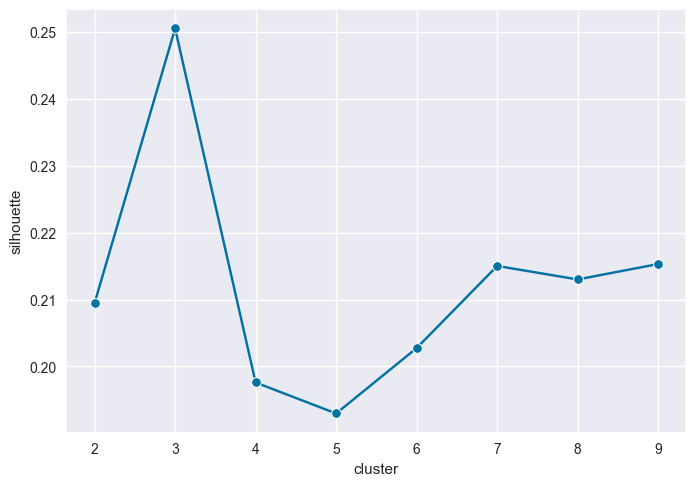

In [96]:
#Теперь можем приступать к кластеризации. Начнём с самого простого и популярного метода — k-means. 
# Для того чтобы его применить, необходимо узнать число кластеров. 
# Наилучший способ сделать это — применить коэффициент силуэта. Найдите с его помощью оптимальное количество кластеров, 
# перебрав диапазон от 2 до 9 включительно. В этом и следующем заданиях для параметра random_state возьмём значение 42, 
# параметр init='random'

# напишем функцию, как и при подсчете метода локтя
def get_silhouette(cluster_num, x):
    k_means =  KMeans(n_clusters=cluster_num, random_state=42, init='random')
    k_means.fit(x)
# подсчитаем метрику силуэта, передав данные и то, к каким кластерам относятся объекты
    silhouette = silhouette_score(x, k_means.predict(x))
    return silhouette

# создадим пустой словарь, ключами будут инерция и количество кластеров
silhouette_res = {"silhouette": [], "cluster": []}

for cluster_num in range(2, 10):
    silhouette_res["silhouette"].append(get_silhouette(cluster_num, df_norm))
    silhouette_res["cluster"].append(cluster_num)
    
# сохраним в датафрейм значение силуэта и количество кластеров
silhouette_df = pd.DataFrame(silhouette_res)

# установим стиль для визуализиции
sns.set_style("darkgrid")
# визуализируем зависимость значения инерции от количества кластеров
sns.lineplot(data=silhouette_df, x="cluster", y="silhouette", marker= "o")

In [97]:
clasters_numb = silhouette_df.sort_values(by='silhouette', ascending=False).iloc[0,1]
clasters_numb

np.int64(3)

In [98]:
# Теперь реализуем непосредственно кластеризацию k-means с оптимальным количеством кластеров, 
# которое мы определили в предыдущем задании. Сколько человек оказалось в самой малочисленной группе?
df_KM = df.copy()
KM = KMeans(random_state=42, init='random', n_clusters=clasters_numb)
df_KMed = KM.fit_predict(df_norm)
df_KM.loc[:, 'label'] = KM.labels_
df_KM['label'].value_counts(ascending=False).values[0]


np.int64(6119)

In [99]:
#Попробуем применить DBSCAN. Для начала реализуйте его с параметрами по умолчанию.
#Сколько кластеров было выделено?
DB = DBSCAN().fit_predict(df_norm)
list(set(DB))[-2]

np.int64(37)

In [100]:
#Давайте попробуем с помощью цикла перебрать параметр eps по значениям, заданным как np.arange(0.1,3,0.2), 
# а параметр min_samples — по значениям, заданным как range(1,20,4). 
# Найдите комбинацию, которая даёт максимальное значение коэффициента силуэта.
def get_silhouette_DB(eps, ms, x):
    DBS =  DBSCAN(eps=eps, min_samples=ms)
# подсчитаем метрику силуэта, передав данные и то, к каким кластерам относятся объекты
    silhouette = silhouette_score(x, DBS.fit_predict(x))
    return silhouette

# создадим пустой словарь, ключами будут инерция, количество кластеров и параметры
silhouette_res_DB = {"silhouette": [], "cluster": [], "eps":[], "min_sample":[]}

for eps in np.arange(0.1,3,0.2):
    for ms in range(1,20,4):
        silhouette_res_DB["silhouette"].append(round(get_silhouette_DB(eps, ms, df_norm), 2))
        silhouette_res_DB["cluster"].append(cluster_num)
        silhouette_res_DB["eps"].append(eps)
        silhouette_res_DB["min_sample"].append(ms)
    
# сохраним в датафрейм значение силуэта и количество кластеров
silhouette_df_DB = pd.DataFrame(silhouette_res_DB)
silhouette_df_DB.sort_values(by='silhouette', ascending=False)


,silhouette,cluster,eps,min_sample
71,0.62,9,2.9,5
72,0.60,9,2.9,9
73,0.60,9,2.9,13
66,0.59,9,2.7,5
74,0.59,9,2.9,17
...,...,...,...,...
7,-0.40,9,0.3,9
25,-0.40,9,1.1,1
6,-0.42,9,0.3,5
16,-0.44,9,0.7,5


<Axes: xlabel='cluster', ylabel='silhouette'>

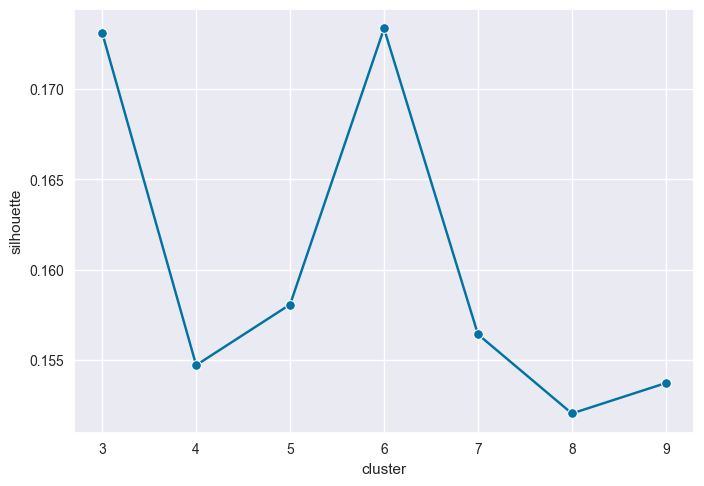

In [101]:
# напишем функцию, как и при подсчете метода локтя
def get_silhouette_AC(cluster_num, x):
    AC =  AgglomerativeClustering(n_clusters=cluster_num)
    #AC.fit(x)
# подсчитаем метрику силуэта, передав данные и то, к каким кластерам относятся объекты
    silhouette = silhouette_score(x, AC.fit_predict(x))
    return silhouette

# создадим пустой словарь, ключами будут инерция и количество кластеров
silhouette_res_AC = {"silhouette": [], "cluster": []}

for cluster_num in range(3, 10):
    silhouette_res_AC["silhouette"].append(get_silhouette_AC(cluster_num, df_norm))
    silhouette_res_AC["cluster"].append(cluster_num)
    
# сохраним в датафрейм значение силуэта и количество кластеров
silhouette_df_AC = pd.DataFrame(silhouette_res_AC)

# установим стиль для визуализиции
sns.set_style("darkgrid")
# визуализируем зависимость значения инерции от количества кластеров
sns.lineplot(data=silhouette_df_AC, x="cluster", y="silhouette", marker= "o")

In [102]:
clasters_numb_AC = silhouette_df_AC.sort_values(by='silhouette', ascending=False).iloc[0,1]
clasters_numb_AC

np.int64(6)

In [103]:
#Сколько будет наблюдений в самом многочисленном классе, 
# если мы обучим на наших данных модель агломеративной иерархической кластеризации с количеством кластеров, 
# полученным в предыдущем задании?
df_AC = df.copy()
AC_best_param = AgglomerativeClustering(n_clusters=clasters_numb_AC)
result = AC_best_param.fit_predict(df_norm)
df_AC.loc[:, 'label'] = AC_best_param.labels_
df_AC['label'].value_counts(ascending=False).values[0]

np.int64(3946)

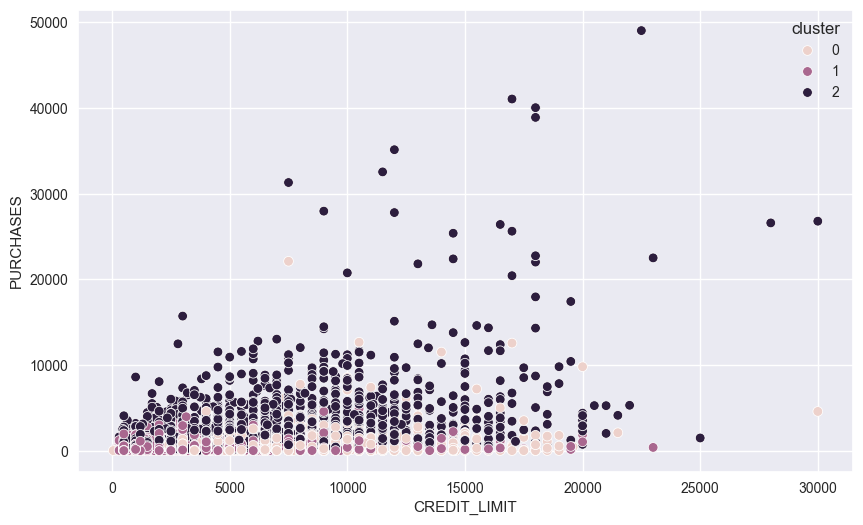

In [104]:
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(df_norm)
df['cluster'] = kmeans.labels_
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='CREDIT_LIMIT', y='PURCHASES', hue='cluster')
plt.show()